## Temporal Fusion Transformer

From our earlier experiments with different models, we came to the conclusion that it is better to focus on the time period for which the forecast data is available ( 2024 onwards).  Hence we will only consider data for that period and train a deep learning model based on temporal fusion transformer. For this purpose, we will be using the PyTorch Forecasting library.

In [1]:
# General
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import json
from pathlib import Path
import pickle
import itertools

import lightning.pytorch as pl 
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger

# From PyTorch
import torch
from torch.nn import BCEWithLogitsLoss
import torch.nn as nn
import torch.nn.functional as F

# From PyTorch Forecasting
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MAE, SMAPE, PoissonLoss, QuantileLoss, CrossEntropy
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters
from pytorch_forecasting.tuning import Tuner
from pytorch_forecasting.metrics import MultiHorizonMetric, Metric

# From sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score,precision_recall_curve,confusion_matrix, 
classification_report)


In [2]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')   # Mac's gpu
else:
    device = torch.device('cpu')

print(f"Using device ; {device}")

class BCEWithLogitsLossWrapper(MultiHorizonMetric):
    def __init__(self,pos_weight=None):
        super().__init__()
        self.criterion = BCEWithLogitsLoss(pos_weight=pos_weight)

    def loss(self, y_pred, target):
        # if model outputs [batch, 1] or [batch, 1, 1]
        y_pred = y_pred.squeeze(-1)
        return self.criterion(y_pred, target.float())


class PRAUCMetric(Metric):
    def __init__(self):
        super().__init__()
        self.metric = AveragePrecision(task="binary")

    def update(self, preds, target):


        preds = torch.sigmoid(preds.squeeze(-1)).view(-1)


        if isinstance(target, (tuple, list)):
            target = target[0]

        target = target.view(-1)
        target = target.long()

        self.metric.update(preds, target)

    def compute(self):
        return self.metric.compute()

Using device ; mps


## Forecast weather model

We will use PyTorch Forecasting library to implement our Temporal Fusion Transformer (TFT) model. In order to use this,
it is important to add a time index that is incremented by one for each time step

In [3]:
lookback = 24
learning_rate = 3e-4
max_epochs = 30
patience = 5
batch_size = 64
max_prediction_length = 1

# Relevant timestamps
valid_start = pd.Timestamp("2025-07-01", tz="UTC")
test_start = pd.Timestamp("2025-12-01", tz="UTC")


In [4]:
# Loading processed data
df_feature_file = (pd.read_csv(f"feature_combined_data_2019-05-01_2026-05-01.csv",parse_dates=["timestamp_utc"]
                            ).set_index("timestamp_utc").sort_index())
df_forecast = ( pd.read_csv(f"forecast_data_2024-03-01_2026-05-02.csv",parse_dates=["timestamp_utc"]
                            ).set_index("timestamp_utc").sort_index())

df_feature_file['time_idx'] =  np.arange(len(df_feature_file))
calendar_cols = ["hour_sin","hour_cos","day_of_week_sin","day_of_week_cos","month_sin","month_cos",]

observed_cols = [c for c in df_feature_file.columns if c.startswith("observed_")]
forecast_cols = [c for c in df_forecast.columns if c.startswith("forecast_")]
smard_input_cols = [c for c in df_feature_file.columns if c not in calendar_cols + ["Negative_price"] + observed_cols]

observed_weather = df_feature_file[observed_cols].rename(columns=lambda c: c.replace("observed_", ""))
forecast_weather = df_forecast[forecast_cols].rename(columns=lambda c: c.replace("forecast_", ""))

if sorted(observed_weather.columns) != sorted(forecast_weather.columns):
    raise ValueError("Observed and forecast weather columns do not match after removing prefixes")

target = "Negative_price"
weather_cols = list(df_forecast.columns)
reals = calendar_cols + smard_input_cols + weather_cols
scalers = {feature: StandardScaler()for feature in reals}
time_varying_known_reals = (calendar_cols + weather_cols)
time_varying_unknown_reals = smard_input_cols



In PyTorch forecasting, the dataset containing both the training and validation set is passed together.
So we split the data accordingly. In order to automate the dataset creation process, we define a function which would create the dataset based on the lookback period

In [ ]:
def build_tft_dataset(df_feature,df_forecast,calendar_cols,smard_input_cols,test_start,lookback=24):

    # Align time range
    start_date = max(df_feature.index.min(), df_forecast.index.min())

    df = df_feature.loc[start_date:test_start].copy()
    df_weather = df_forecast.loc[start_date:test_start].copy()

    # Remove observed weather 
    df = df.drop(columns=[c for c in df.columns if c.startswith("observed_")])

    # Join forecast weather (aligned to time t)
    df = df.join(df_weather, how="inner")

    # Target: predict t+24 negative price
    df["target"] = df["Negative_price"].shift(-24)

    # Shift forecast weather to the same prediction horizon
    forecast_cols = df_forecast.columns
    df[forecast_cols] = df[forecast_cols].shift(-24)
    
    # Remove rows where either the target or shifted weather is missing
    df = df.dropna(subset=["target"] + list(forecast_cols)).copy()

    # Clean duplicates
    df = df.loc[:, ~df.columns.duplicated()]

    # Rebuild time index
    df = df.drop(columns=["time_idx"], errors="ignore")
    df["time_idx"] = np.arange(len(df))

    df["series"] = 0

    # Feature columns
    cols = (
        calendar_cols
        + smard_input_cols
        + list(df_forecast.columns)
        + ["time_idx", "series", "target"]
    )
    cols = list(dict.fromkeys(cols))

    df_tft = df[cols]

    # Train / full pre-test split
    data = df_tft[df_tft.index < test_start]

    # include enough history for encoder + horizon
    test_data = df_tft[
        df_tft.index >= (test_start - pd.Timedelta(hours=lookback+24 ))
    ].copy()

    return df_tft, data, test_data

In [6]:
df_tft, data, test_data = build_tft_dataset(df_feature_file,df_forecast,calendar_cols,
                                            smard_input_cols,test_start,lookback=lookback)

train_data = data[data.index < valid_start]

training = TimeSeriesDataSet(train_data,time_idx="time_idx",target="target",group_ids=["series"],
                              max_encoder_length=lookback,max_prediction_length=1,
                              time_varying_known_reals=time_varying_known_reals,
                              time_varying_unknown_reals=time_varying_unknown_reals,
                              add_relative_time_idx=True,add_target_scales=False,add_encoder_length=True,)

validation_data = data[(data.index >= valid_start) & (data.index < test_start)]

validation = TimeSeriesDataSet.from_dataset(training,validation_data,stop_randomization=True)

test_dataset = TimeSeriesDataSet.from_dataset(training,test_data,stop_randomization=True)

# imbalance handling 
n_pos = train_data["target"].sum()
n_neg = len(train_data) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)

train_loader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=2,persistent_workers=True)
val_loader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

## Learning rate

In [7]:
tft = TemporalFusionTransformer.from_dataset(training,learning_rate=3e-4,hidden_size=16,
    attention_head_size=4,dropout=0.1,hidden_continuous_size=8, output_size=1,
    loss=BCEWithLogitsLossWrapper(pos_weight=pos_weight))

tft = tft.to(device)

early_stop = EarlyStopping(monitor="val_loss", patience=5, mode="min")
lr_logger = LearningRateMonitor()

trainer = pl.Trainer(accelerator="auto",devices=1,callbacks=[lr_logger, early_stop],gradient_clip_val=0.1,)
res = Tuner(trainer).lr_find(tft,train_dataloaders=train_loader,val_dataloaders=val_loader,min_lr=1e-5,max_lr=1.0,)

/Users/ranadeeproy/Desktop/erdos_ds_environment_2026/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/Users/ranadeeproy/Desktop/erdos_ds_environment_2026/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/ranadeeproy/Desktop/erdos_ds_environment_2026/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Restoring states from the checkpoint path at /Users/ranadeeproy/Desktop/others/energy_sector/smard/new/new_TFT/.lr_find_5861b52a-6991-41f7-ae15-8d1ca39ff641.ckpt
Restored all states from the checkpoint at /Users/ranadeeproy/Desktop/others/energy_sector/smard/new/new_TFT/.lr_find_5861b52a-6991-41f7-ae15-8d1ca39ff641.ckpt
Learning rate set to 3.548133892335755e-05


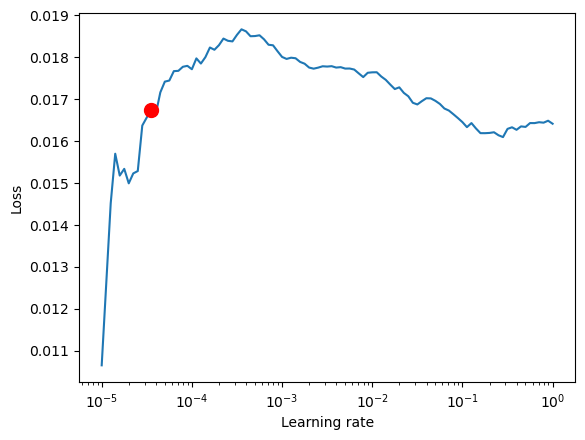

Best LR: 3.548133892335755e-05


In [8]:

fig = res.plot(suggest=True)
plt.show()

best_lr = res.suggestion()
print("Best LR:", best_lr)

In [9]:
lrs = res.results["lr"]
losses = res.results["loss"]

for lr, loss in zip(lrs, losses):
    print(f"lr={lr:.3e}, loss={loss:.6f}")

lr=1.000e-05, loss=0.010648
lr=1.259e-05, loss=0.014515
lr=1.413e-05, loss=0.015697
lr=1.585e-05, loss=0.015176
lr=1.778e-05, loss=0.015336
lr=1.995e-05, loss=0.014990
lr=2.239e-05, loss=0.015227
lr=2.512e-05, loss=0.015283
lr=2.818e-05, loss=0.016369
lr=3.162e-05, loss=0.016562
lr=3.548e-05, loss=0.016744
lr=3.981e-05, loss=0.016647
lr=4.467e-05, loss=0.017160
lr=5.012e-05, loss=0.017417
lr=5.623e-05, loss=0.017443
lr=6.310e-05, loss=0.017667
lr=7.079e-05, loss=0.017674
lr=7.943e-05, loss=0.017771
lr=8.913e-05, loss=0.017794
lr=1.000e-04, loss=0.017712
lr=1.122e-04, loss=0.017971
lr=1.259e-04, loss=0.017848
lr=1.413e-04, loss=0.018001
lr=1.585e-04, loss=0.018231
lr=1.778e-04, loss=0.018177
lr=1.995e-04, loss=0.018286
lr=2.239e-04, loss=0.018444
lr=2.512e-04, loss=0.018391
lr=2.818e-04, loss=0.018377
lr=3.162e-04, loss=0.018533
lr=3.548e-04, loss=0.018665
lr=3.981e-04, loss=0.018617
lr=4.467e-04, loss=0.018500
lr=5.012e-04, loss=0.018504
lr=5.623e-04, loss=0.018523
lr=6.310e-04, loss=0

In [10]:
tft = TemporalFusionTransformer.from_dataset(training,learning_rate=3e-4,hidden_size=16,
    attention_head_size=4,dropout=0.1,hidden_continuous_size=8, output_size=1,
    loss=BCEWithLogitsLossWrapper(pos_weight=pos_weight))

tft = tft.to(device)

early_stop = EarlyStopping(monitor="val_loss", patience=5, mode="min")
lr_logger = LearningRateMonitor()

trainer = pl.Trainer(accelerator="auto",devices=1,callbacks=[lr_logger, early_stop],gradient_clip_val=0.1,)
res = Tuner(trainer).lr_find(tft,train_dataloaders=train_loader,val_dataloaders=val_loader,min_lr=1e-7,max_lr=1e-5,)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`weights_only` was not set, defaulting to `False`.


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Restoring states from the checkpoint path at /Users/ranadeeproy/Desktop/others/energy_sector/smard/new/new_TFT/.lr_find_22490a6a-0672-4a74-9713-0db7e8bd7c34.ckpt
Restored all states from the checkpoint at /Users/ranadeeproy/Desktop/others/energy_sector/smard/new/new_TFT/.lr_find_22490a6a-0672-4a74-9713-0db7e8bd7c34.ckpt
Learning rate set to 1.6595869074375607e-07


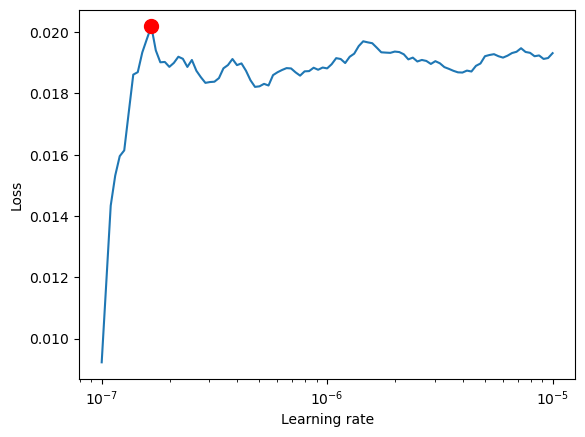

Best LR: 1.6595869074375607e-07


In [11]:

fig = res.plot(suggest=True)
plt.show()

best_lr = res.suggestion()
print("Best LR:", best_lr)

We note that the suggested learning rate is extremely small.  We will proceed with learning rate = 3e-4 and decrease it if necessary

## Training -BCEWithLogitsLoss
From now on, we will use the learning rate to be 3e-4. For LSTM modeling, we had used BCEWithLogitsLoss with pos_weight to handle class imbalance. Also, we had used early stopping based on best PR-AUC value. <br>

PyTorch Forecasting is mainly designed for forecasting which is essentially a regression problem. When we create a TFT model, we specify a loss: <br>


The loss object has two tasks:
1. Compute the training loss <br>
2. Provide metrics to log during training/validation <br>

For example, we may use loss= QuantileLoss(). The TFT would log things like : train_loss and val_loss and ealy stopping would usually monitor: <br>
monitor = "val_loss" <br>
mode    = "min" <br>

For a binary classification problem like ours, if we use: <br>
loss = BCEWithLogitsLoss(..) <br>

we will get an error because no metric called is logged. Hence, in the beginning of this notebook, we had defined a custom class for BCEWithLogitsLoss and a wrapper to deal with this

In [12]:
lookback = 24
learning_rate = 3e-4
max_epochs = 30
patience = 5
batch_size = 64
max_prediction_length = 1

In [13]:
print(pos_weight)
    
tft = TemporalFusionTransformer.from_dataset(training,learning_rate=3e-4,hidden_size=16,
    attention_head_size=4,dropout=0.1,hidden_continuous_size=8, output_size=1,
    loss=BCEWithLogitsLossWrapper(pos_weight=pos_weight))


tensor([13.1501], device='mps:0')


In [14]:

early_stop = EarlyStopping(monitor="val_loss",patience=5,mode="min")
lr_logger = LearningRateMonitor()
trainer = pl.Trainer(max_epochs=30,accelerator="auto",devices=1,gradient_clip_val=0.1,callbacks=[early_stop, lr_logger],
                     enable_progress_bar=True,)

trainer.fit(tft,train_dataloaders=train_loader,val_dataloaders=val_loader,)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | BCEWithLogitsLossWrapper        | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 0      

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/ranadeeproy/Desktop/erdos_ds_environment_2026/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [15]:
trainer.state.finished

True

In [16]:
raw_preds = tft.predict(val_loader,mode='raw')
preds = raw_preds.prediction
probs= torch.sigmoid(preds).squeeze()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/ranadeeproy/Desktop/erdos_ds_environment_2026/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


In [17]:
y_true = torch.cat([y[0] for _,y in val_loader]).cpu().numpy()
probs = probs.view(-1)
y_true = torch.tensor(y_true).view(-1)
print("mean prob (neg cases):", probs[y_true == 0].mean().item())
print("mean prob (pos cases):", probs[y_true == 1].mean().item())

mean prob (neg cases): 0.4370322823524475
mean prob (pos cases): 0.8657175898551941


In [18]:
from sklearn.metrics import roc_auc_score, average_precision_score

if device != 'cpu':
    roc_auc_2 = roc_auc_score(y_true.numpy(), probs.cpu().numpy())
    pr_auc_2 = average_precision_score(y_true.numpy(), probs.cpu().numpy())
else:
    roc_auc_2 = roc_auc_score(y_true.numpy(), probs.numpy())
    pr_auc_2 = average_precision_score(y_true.numpy(), probs.numpy())


print(f"ROC-AUC : {roc_auc_2:.4f}")
print(f"PR-AUC  : {pr_auc_2:.4f}")

ROC-AUC : 0.9264
PR-AUC  : 0.7748


In [19]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix, classification_report

if device != 'cpu':
    precision, recall, thresholds = precision_recall_curve(y_true.numpy(),probs.cpu().numpy())
else:
    precision, recall, thresholds = precision_recall_curve(y_true.numpy(),probs.numpy())

# F1 for each threshold
f1_2 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-8)

best_idx = np.argmax(f1_2)

best_threshold = thresholds[best_idx]
best_f1 = f1_2[best_idx]

print(f"Best threshold = {best_threshold:.4f}")
print(f"Best F1        = {best_f1:.4f}")
print(f"Precision      = {precision[best_idx]:.4f}")
print(f"Recall         = {recall[best_idx]:.4f}")

Best threshold = 0.8981
Best F1        = 0.7617
Precision      = 0.7277
Recall         = 0.7989


In [20]:

if device != 'cpu':
    pred = (probs.cpu().numpy() >= best_threshold).astype(int)
else:
    pred = (probs.numpy() >= best_threshold).astype(int)


print(confusion_matrix(y_true.numpy(), pred))
print(classification_report(y_true.numpy(), pred, digits=4))

[[3386   55]
 [  37  147]]
              precision    recall  f1-score   support

         0.0     0.9892    0.9840    0.9866      3441
         1.0     0.7277    0.7989    0.7617       184

    accuracy                         0.9746      3625
   macro avg     0.8585    0.8915    0.8741      3625
weighted avg     0.9759    0.9746    0.9752      3625



We see tha even without hyperparameter tuning, the model performs reasonably well with the best F1 score of 0.76. 

##  Training - Focal Loss

In LSTM, it was noted for our dataset, the model performed better with focal loss rather than BCEWithLogitsLoss. Hence, we also train a TFT model with this loss fucntion

In [21]:

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.float()

        bce_loss = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none",
        )

        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)

        alpha_t = torch.where(
            targets == 1,
            self.alpha,
            1 - self.alpha,
        )

        loss = alpha_t * (1 - pt) ** self.gamma * bce_loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss

class FocalLossWrapper(MultiHorizonMetric):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.criterion = FocalLoss(alpha=alpha, gamma=gamma)

    def loss(self, y_pred, target):
        y_pred = y_pred.squeeze(-1)
        target = target.float()
        return self.criterion(y_pred, target)

In [22]:

    
tft2 = TemporalFusionTransformer.from_dataset(training,learning_rate=3e-4,hidden_size=16,
    attention_head_size=4,dropout=0.1,hidden_continuous_size=8, output_size=1,
    loss=FocalLossWrapper(alpha=0.25,gamma=2.0))


/Users/ranadeeproy/Desktop/erdos_ds_environment_2026/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/Users/ranadeeproy/Desktop/erdos_ds_environment_2026/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [23]:

early_stop = EarlyStopping(monitor="val_loss",patience=5,mode="min")
lr_logger = LearningRateMonitor()
trainer = pl.Trainer(max_epochs=30,accelerator="auto",devices=1,gradient_clip_val=0.1,callbacks=[early_stop, lr_logger],
                     enable_progress_bar=True,)

trainer.fit(tft2,train_dataloaders=train_loader,val_dataloaders=val_loader,)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | FocalLossWrapper                | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 0      

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/ranadeeproy/Desktop/erdos_ds_environment_2026/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/ranadeeproy/Desktop/erdos_ds_environment_2026/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [24]:
trainer.state.finished

True

In [25]:
raw_preds_2 = tft2.predict(val_loader,mode='raw')
preds_2 = raw_preds_2.prediction
probs_2= torch.sigmoid(preds_2).squeeze()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/ranadeeproy/Desktop/erdos_ds_environment_2026/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


In [26]:
y_true = torch.cat([y[0] for _,y in val_loader]).cpu().numpy()
probs_2 = probs_2.view(-1)
y_true = torch.tensor(y_true).view(-1)
print("mean prob (neg cases):", probs_2[y_true == 0].mean().item())
print("mean prob (pos cases):", probs_2[y_true == 1].mean().item())

mean prob (neg cases): 0.4425651729106903
mean prob (pos cases): 0.49398770928382874


In [27]:
from sklearn.metrics import roc_auc_score, average_precision_score

if device != 'cpu':
    roc_auc_2 = roc_auc_score(y_true.numpy(), probs_2.cpu().numpy())
    pr_auc_2 = average_precision_score(y_true.numpy(), probs_2.cpu().numpy())
else:
    roc_auc_2 = roc_auc_score(y_true.numpy(), probs_2.numpy())
    pr_auc_2 = average_precision_score(y_true.numpy(), probs_2.numpy())


print(f"ROC-AUC : {roc_auc_2:.4f}")
print(f"PR-AUC  : {pr_auc_2:.4f}")

ROC-AUC : 0.5974
PR-AUC  : 0.4631


In [28]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix, classification_report

if device != 'cpu':
    precision_2, recall_2, thresholds_2 = precision_recall_curve(y_true.numpy(),probs_2.cpu().numpy())
else:
    precision_2, recall_2, thresholds_2 = precision_recall_curve(y_true.numpy(),probs_2.numpy())

# F1 for each threshold
f1_2 = 2 * precision_2[:-1] * recall_2[:-1] / (precision_2[:-1] + recall_2[:-1] + 1e-8)

best_idx_2 = np.argmax(f1_2)

best_threshold_2 = thresholds_2[best_idx_2]
best_f1_2 = f1_2[best_idx_2]

print(f"Best threshold = {best_threshold_2:.4f}")
print(f"Best F1        = {best_f1_2:.4f}")
print(f"Precision      = {precision_2[best_idx_2]:.4f}")
print(f"Recall         = {recall_2[best_idx_2]:.4f}")

Best threshold = 0.5021
Best F1        = 0.5695
Precision      = 0.7568
Recall         = 0.4565


In [29]:

if device != 'cpu':
    pred = (probs_2.cpu().numpy() >= best_threshold_2).astype(int)
else:
    pred = (probs_2.numpy() >= best_threshold_2).astype(int)


print(confusion_matrix(y_true.numpy(), pred))
print(classification_report(y_true.numpy(), pred, digits=4))

[[3414   27]
 [ 100   84]]
              precision    recall  f1-score   support

         0.0     0.9715    0.9922    0.9817      3441
         1.0     0.7568    0.4565    0.5695       184

    accuracy                         0.9650      3625
   macro avg     0.8641    0.7243    0.7756      3625
weighted avg     0.9606    0.9650    0.9608      3625



We note that this model performs considerably worse than the previous one.  We will now change alpha parameter and see if  it improves or not

### Changing alpha to 0.75

In [30]:

    
tft3 = TemporalFusionTransformer.from_dataset(training,learning_rate=3e-4,hidden_size=16,
    attention_head_size=4,dropout=0.1,hidden_continuous_size=8, output_size=1,
    loss=FocalLossWrapper(alpha=0.75,gamma=2.0))


/Users/ranadeeproy/Desktop/erdos_ds_environment_2026/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/Users/ranadeeproy/Desktop/erdos_ds_environment_2026/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [31]:

early_stop = EarlyStopping(monitor="val_loss",patience=5,mode="min")
lr_logger = LearningRateMonitor()
trainer = pl.Trainer(max_epochs=30,accelerator="auto",devices=1,gradient_clip_val=0.1,callbacks=[early_stop, lr_logger],
                     enable_progress_bar=True,)

trainer.fit(tft3,train_dataloaders=train_loader,val_dataloaders=val_loader,)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | FocalLossWrapper                | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 0      

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/ranadeeproy/Desktop/erdos_ds_environment_2026/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/ranadeeproy/Desktop/erdos_ds_environment_2026/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [32]:
trainer.state.finished

True

In [33]:
raw_preds_3 = tft3.predict(val_loader,mode='raw')
preds_3 = raw_preds_3.prediction
probs_3= torch.sigmoid(preds_3).squeeze()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/ranadeeproy/Desktop/erdos_ds_environment_2026/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


In [34]:
y_true = torch.cat([y[0] for _,y in val_loader]).cpu().numpy()
probs_3 = probs_3.view(-1)
y_true = torch.tensor(y_true).view(-1)
print("mean prob (neg cases):", probs_3[y_true == 0].mean().item())
print("mean prob (pos cases):", probs_3[y_true == 1].mean().item())

mean prob (neg cases): 0.4549678564071655
mean prob (pos cases): 0.6847240924835205


In [35]:
from sklearn.metrics import roc_auc_score, average_precision_score

if device != 'cpu':
    roc_auc_3 = roc_auc_score(y_true.numpy(), probs_3.cpu().numpy())
    pr_auc_3 = average_precision_score(y_true.numpy(), probs_3.cpu().numpy())
else:
    roc_auc_3 = roc_auc_score(y_true.numpy(), probs.numpy())
    pr_auc_3 = average_precision_score(y_true.numpy(), probs_3.numpy())


print(f"ROC-AUC : {roc_auc_3:.4f}")
print(f"PR-AUC  : {pr_auc_3:.4f}")

ROC-AUC : 0.8819
PR-AUC  : 0.7191


In [36]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix, classification_report

if device != 'cpu':
    precision_3, recall_3, thresholds_3 = precision_recall_curve(y_true.numpy(),probs_3.cpu().numpy())
else:
    precision_3, recall_3, thresholds_3 = precision_recall_curve(y_true.numpy(),probs_3.numpy())

# F1 for each threshold
f1_3 = 2 * precision_3[:-1] * recall_3[:-1] / (precision_3[:-1] + recall_3[:-1] + 1e-8)

best_idx_3 = np.argmax(f1_3)

best_threshold_3 = thresholds_3[best_idx_3]
best_f1_3 = f1_3[best_idx_3]

print(f"Best threshold = {best_threshold_3:.4f}")
print(f"Best F1        = {best_f1_3:.4f}")
print(f"Precision      = {precision_3[best_idx_3]:.4f}")
print(f"Recall         = {recall_3[best_idx_3]:.4f}")

Best threshold = 0.5980
Best F1        = 0.7196
Precision      = 0.7010
Recall         = 0.7391


In [37]:

if device != 'cpu':
    pred = (probs_3.cpu().numpy() >= best_threshold_3).astype(int)
else:
    pred = (probs_3.numpy() >= best_threshold_3).astype(int)


print(confusion_matrix(y_true.numpy(), pred))
print(classification_report(y_true.numpy(), pred, digits=4))

[[3383   58]
 [  48  136]]
              precision    recall  f1-score   support

         0.0     0.9860    0.9831    0.9846      3441
         1.0     0.7010    0.7391    0.7196       184

    accuracy                         0.9708      3625
   macro avg     0.8435    0.8611    0.8521      3625
weighted avg     0.9715    0.9708    0.9711      3625



We note that changing alpha to a higher value has improved the performance significantly. However, it is still lower than BCEWithLogitsLoss. Hence, we will proceed with BCEWithLogitsLoss and perform hyperparameter tuning with lr=3e-4